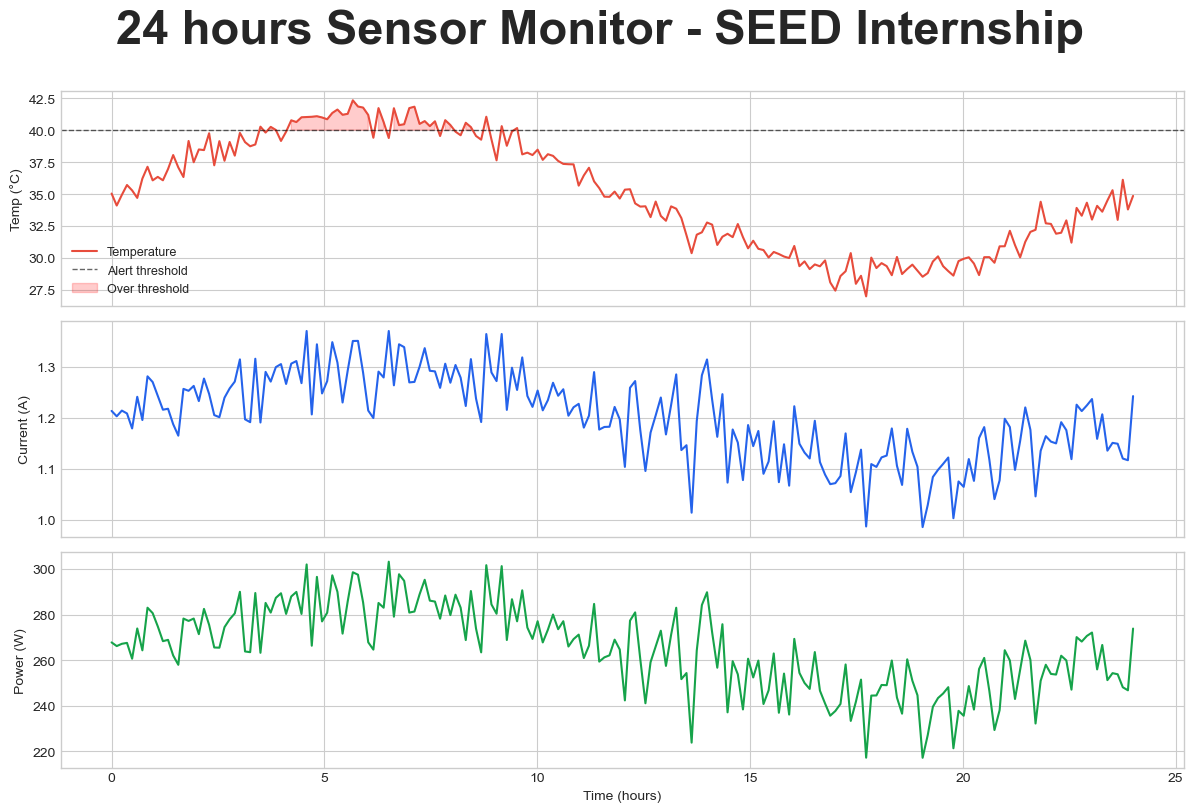

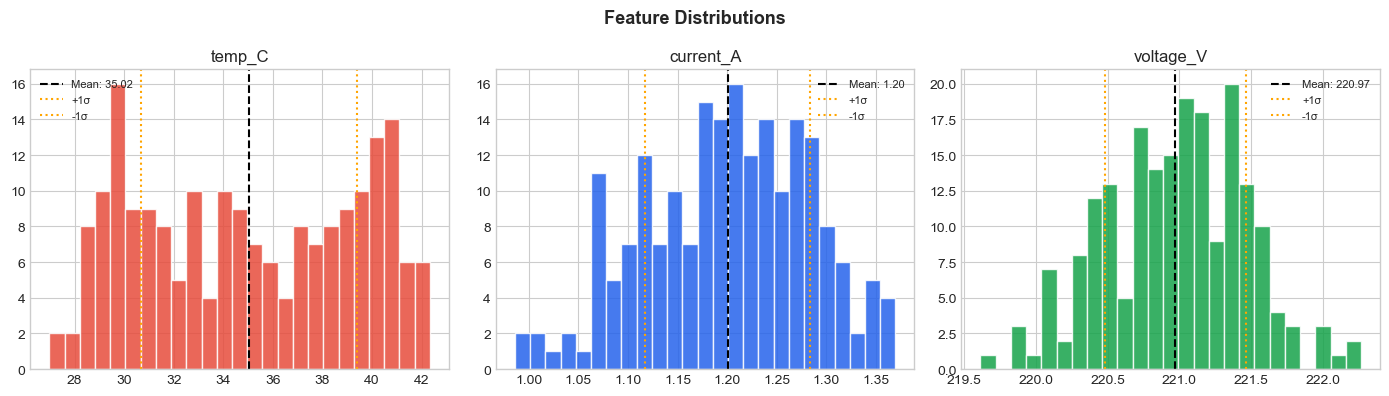

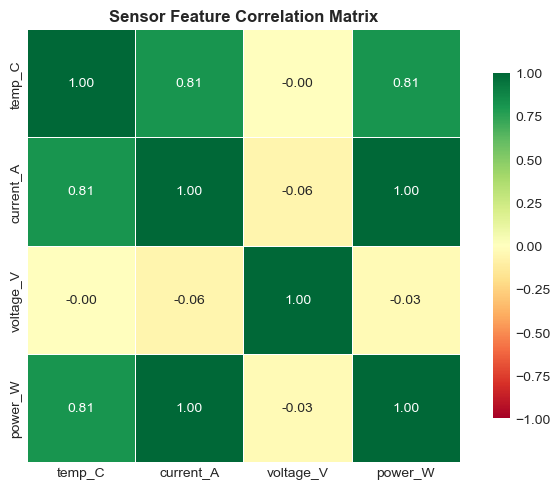

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#import pandas as pd

#plt.style.use("seaborn-v0_8-whitegrid") # clean white backgroung
#sns.set_palette("table10") # distinct colour palette

#np.random.seed(0) # generates random numbers that will not change as the code is restarted
n = 200
t = np.linspace(0, 24, n) # generates numbers from 0 to 24 and they should be n of them (200 of them). 24 hours

# Temperature: sinusoildal daily cycle + Gaussian noise
temp = 35 + 6 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 0.8, n)

# current: correlation with temperature (motor draws more when hot)
current = 1.2 + 0.015 * (temp -35) + np.random.normal(0, 0.05, n)

# voltage: slight negative correlation with load
voltage = 221 - 0.8 * (current - 1.2) + np.random.normal(0, 0.5, n)

df = pd.DataFrame ({"time_h": t, "temp_C": temp, "current_A": current, "voltage_V": voltage})
df["power_W"] = df["voltage_V"] * df["current_A"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex = True)
fig.suptitle("24 hours Sensor Monitor - SEED Internship", fontsize = 34, fontweight = "bold", y = 1.01)

axes[0].plot(df["time_h"], df["temp_C"], color = "#E74C3C", linewidth = 1.5, label="Temperature")

# axes[1].plot(df["time_h"], df["current_A"], color = "cyan", linewidth = 1.5, label = "Current")

# axes[2].plot(df["time_h"], df["voltage_V"], color = "blue", linewidth = 1.5, label = "Voltage")

# plt.tight_layout()
# axes[0].legend(fontsize=20)
# axes[1].legend(fontsize=23)
# axes[2].legend(fontsize=23)

axes[0].axhline(y=40, color="black", linestyle="--", alpha=0.6, linewidth=1, label="Alert threshold")

axes[0].fill_between(df["time_h"], df["temp_C"], 40, where=(df["temp_C"] > 40), color="red", alpha=0.2, label="Over threshold")

axes[0].set_ylabel("Temp (°C)", fontsize=10)

axes[0].legend(fontsize=9)


axes[1].plot(df["time_h"], df["current_A"], color="#2563EB", linewidth=1.5)

axes[1].set_ylabel("Current (A)", fontsize=10)

axes[2].plot(df["time_h"], df["power_W"], color="#16A34A", linewidth=1.5)

axes[2].set_ylabel("Power (W)", fontsize=10)

axes[2].set_xlabel("Time (hours)", fontsize=10)

plt.tight_layout()
plt.savefig("sensor_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

# Histogram Graph
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

fig.suptitle("Feature Distributions", fontsize=13, fontweight="bold") 

for ax, col, colour in zip(axes, ["temp_C", "current_A", "voltage_V"], ["#E74C3C", "#2563EB", "#16A34A"]):
    ax.hist(df[col], bins=25, color=colour, edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="black", linestyle="--", linewidth=1.5, label=f"Mean: {df[col].mean():.2f}")
    ax.axvline(df[col].mean() + df[col].std(), color="orange", linestyle=":", linewidth=1.5, label=f"+1σ")
    ax.axvline(df[col].mean() - df[col].std(), color="orange", linestyle=":", linewidth=1.5, label=f"-1σ")
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150)
plt.show()

# Heatmap
corr = df[["temp_C","current_A","voltage_V","power_W"]].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title("Sensor Feature Correlation Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()


In [50]:
df



,time_h,temp_C,current_A,voltage_V,power_W
0,0.000000,34.006911,1.224172,221.087722,270.649442
1,0.120603,34.593861,1.126598,221.639738,249.698782
2,0.241206,35.272751,1.148411,220.789364,253.556873
3,0.361809,35.059751,1.204810,221.897340,267.344066
4,0.482412,37.386461,1.206550,221.704885,267.498085
...,...,...,...,...,...
195,23.517588,32.873630,1.179517,221.096434,260.787089
196,23.638191,34.783325,1.175817,221.183592,260.071504
197,23.758794,35.082960,1.208198,220.618499,266.550746
198,23.879397,35.217735,1.209065,221.453853,267.752063


In [3]:
df


,time_h,temp_C,current_A,voltage_V,power_W
0,0.000000,36.151613,1.268935,220.595629,279.921514
1,0.120603,36.043671,1.113848,220.857147,246.001252
2,0.241206,34.497059,1.218506,220.230826,268.352642
3,0.361809,36.143843,1.184860,221.420103,262.351790
4,0.482412,35.571966,1.288634,221.226584,285.080001
...,...,...,...,...,...
195,23.517588,35.007271,1.215320,220.625773,268.130872
196,23.638191,33.847803,1.180747,220.607325,260.481503
197,23.758794,35.010154,1.250047,221.200330,276.510781
198,23.879397,33.208422,1.170266,221.424346,259.125346


In [4]:
df.head()


,time_h,temp_C,current_A,voltage_V,power_W
0,0.000000,36.151613,1.268935,220.595629,279.921514
1,0.120603,36.043671,1.113848,220.857147,246.001252
2,0.241206,34.497059,1.218506,220.230826,268.352642
3,0.361809,36.143843,1.184860,221.420103,262.351790
4,0.482412,35.571966,1.288634,221.226584,285.080001
